<a href="https://colab.research.google.com/github/Luiz-Frederico/pbl_fase2_Cardio_IA/blob/main/Ir_Alem_2_CardioIA_MLP_ECG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Baixando o Dataset ECG_Image_Dataset[ Normal-AbNormal ]

In [1]:
!pip install -q kagglehub

import kagglehub

# Download da versão mais recente do dataset
path = kagglehub.dataset_download(
    "y20cs3255ramu/ecg-image-dataset-normal-abnormal"
)

print("Dataset baixado em:")
print(path)

100%|██████████| 650M/650M [00:09<00:00, 71.8MB/s]

Extracting files...


Dataset baixado em:
/root/.cache/kagglehub/datasets/y20cs3255ramu/ecg-image-dataset-normal-abnormal/versions/1


In [3]:
import os

for raiz, pastas, arquivos in os.walk(path):
    nivel = raiz.replace(path, "").count(os.sep)
    indentacao = "    " * nivel

    print(f"{indentacao}{os.path.basename(raiz)}/")

    for arquivo in arquivos[:5]:
        print(f"{indentacao}   {arquivo}")

    if len(arquivos) > 5:
        print(f"{indentacao}    ... + {len(arquivos) - 5} arquivos")

1/
    Crop_Dataset/
        ECG_Abnormal/
           HB   (72).jpg
           HB (251).jpg
           HB (261).jpg
           HB (365).jpg
           HB   (157).jpg
            ... + 541 arquivos
        ECG_Normal/
           Normal (548).jpg
           Normal (311).jpg
           Normal (164).jpg
           Normal (182).jpg
           Normal (832).jpg
            ... + 854 arquivos


## Etapa 1 — Seleção e auditoria do dataset

Nesta etapa é realizada a auditoria inicial do dataset de imagens de ECG, verificando sua adequação ao problema de classificação binária entre **Normal** e **Anormal**.

A análise contempla a distribuição das classes, as dimensões e características das imagens, a integridade dos arquivos e uma inspeção visual de amostras das duas categorias. Essas verificações permitem conhecer a estrutura original dos dados e identificar possíveis limitações antes das etapas de pré-processamento e modelagem.

Nenhuma transformação é aplicada às imagens nesta etapa.

1. DISTRIBUIÇÃO DAS CLASSES
Normal: 859 (61.14%)
Anormal: 546 (38.86%)
Total: 1405

2. CARACTERÍSTICAS DAS IMAGENS
Dimensões:
(2105, 1190): 1405 imagens
Modos:
RGB: 1405 imagens

3. INTEGRIDADE DOS ARQUIVOS
Arquivos verificados: 1405
Arquivos problemáticos: 0

4. INSPEÇÃO VISUAL


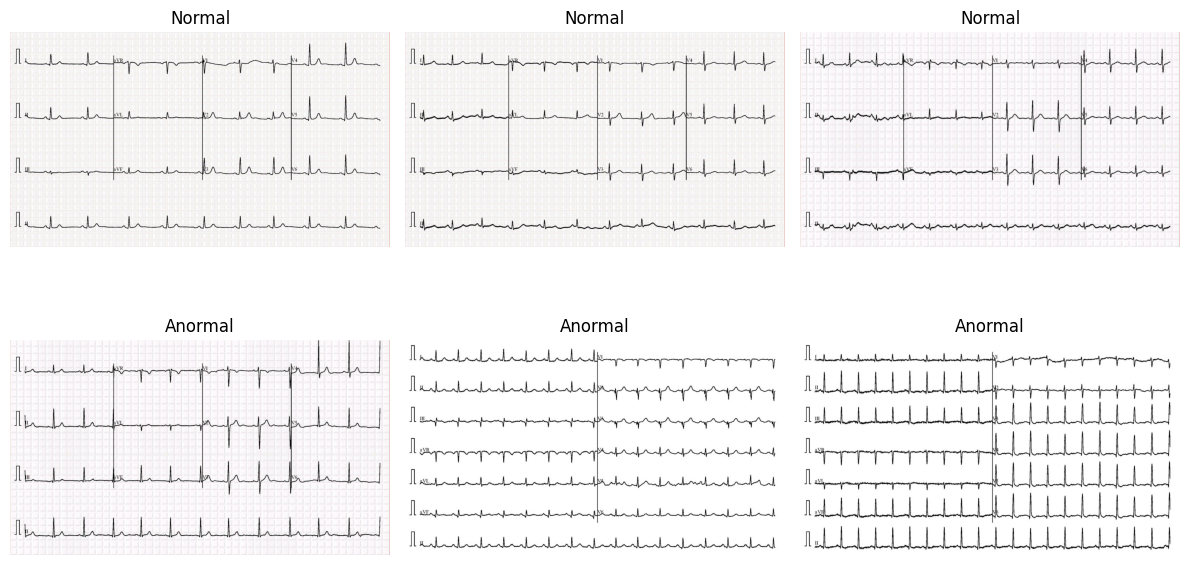

In [4]:
import os
import random
from collections import Counter

import matplotlib.pyplot as plt
from PIL import Image

pasta_normal = os.path.join(path, "Crop_Dataset", "ECG_Normal")
pasta_anormal = os.path.join(path, "Crop_Dataset", "ECG_Abnormal")

arquivos_normal = [
    arquivo for arquivo in os.listdir(pasta_normal)
    if arquivo.lower().endswith((".jpg", ".jpeg", ".png"))
]

arquivos_anormal = [
    arquivo for arquivo in os.listdir(pasta_anormal)
    if arquivo.lower().endswith((".jpg", ".jpeg", ".png"))
]

total_normal = len(arquivos_normal)
total_anormal = len(arquivos_anormal)
total_imagens = total_normal + total_anormal

print("1. DISTRIBUIÇÃO DAS CLASSES")
print(f"Normal: {total_normal} ({total_normal / total_imagens * 100:.2f}%)")
print(f"Anormal: {total_anormal} ({total_anormal / total_imagens * 100:.2f}%)")
print(f"Total: {total_imagens}")

dimensoes = Counter()
modos = Counter()
arquivos_problematicos = []

for pasta, arquivos in [
    (pasta_normal, arquivos_normal),
    (pasta_anormal, arquivos_anormal)
]:
    for arquivo in arquivos:
        caminho = os.path.join(pasta, arquivo)

        try:
            with Image.open(caminho) as imagem:
                dimensoes[imagem.size] += 1
                modos[imagem.mode] += 1
                imagem.verify()
        except Exception as erro:
            arquivos_problematicos.append((caminho, str(erro)))

print("\n2. CARACTERÍSTICAS DAS IMAGENS")
print("Dimensões:")
for dimensao, quantidade in dimensoes.items():
    print(f"{dimensao}: {quantidade} imagens")

print("Modos:")
for modo, quantidade in modos.items():
    print(f"{modo}: {quantidade} imagens")

print("\n3. INTEGRIDADE DOS ARQUIVOS")
print(f"Arquivos verificados: {total_imagens}")
print(f"Arquivos problemáticos: {len(arquivos_problematicos)}")

if arquivos_problematicos:
    for caminho, erro in arquivos_problematicos:
        print(f"{caminho}: {erro}")

print("\n4. INSPEÇÃO VISUAL")

random.seed(42)

amostras = [
    ("Normal", pasta_normal, arquivo)
    for arquivo in random.sample(arquivos_normal, 3)
] + [
    ("Anormal", pasta_anormal, arquivo)
    for arquivo in random.sample(arquivos_anormal, 3)
]

plt.figure(figsize=(12, 7))

for indice, (classe, pasta, arquivo) in enumerate(amostras, start=1):
    with Image.open(os.path.join(pasta, arquivo)) as imagem:
        plt.subplot(2, 3, indice)
        plt.imshow(imagem)
        plt.title(classe)
        plt.axis("off")

plt.tight_layout()
plt.show()

### Conclusão da Etapa 1

O dataset selecionado contém **1.405 imagens de ECG**, sendo 859 normais (61,14%) e 546 anormais (38,86%), indicando desbalanceamento moderado. Todas possuem dimensão **2105 × 1190**, formato RGB e apresentaram integridade válida.

A auditoria estrutural e visual confirmou a adequação do dataset ao problema de classificação **Normal × Anormal**, permitindo sua utilização nas próximas etapas.

---

## Etapa 2 — Análise visual das imagens

Após a seleção e auditoria do dataset, esta etapa busca compreender as características visuais das imagens antes da definição do pré-processamento.

São analisadas amostras das classes **Normal** e **Anormal**, observando elementos como traçados do ECG, fundo quadriculado, contraste, variações de apresentação e possíveis diferenças visuais que não estejam diretamente relacionadas ao sinal cardíaco.

Também é analisada a distribuição das intensidades dos pixels. Conforme abordado no Capítulo 12, uma imagem digital pode ser representada numericamente por seus pixels, permitindo investigar características visuais além da simples exibição da imagem.

Esta análise tem caráter exploratório. Não são estabelecidos critérios médicos próprios para diferenciar ECGs normais e anormais, e nenhuma transformação definitiva ou filtragem é aplicada ao dataset nesta etapa. O objetivo é produzir evidências que orientem as decisões posteriores de pré-processamento.

1. INSPEÇÃO VISUAL DAS CLASSES


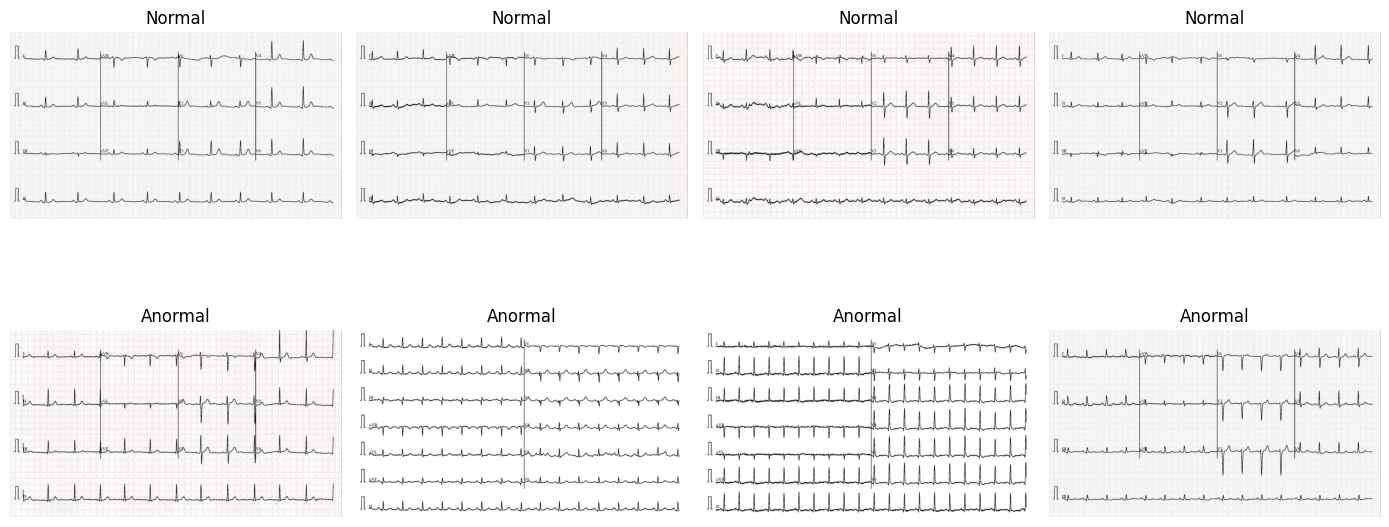


2. DISTRIBUIÇÃO DAS INTENSIDADES


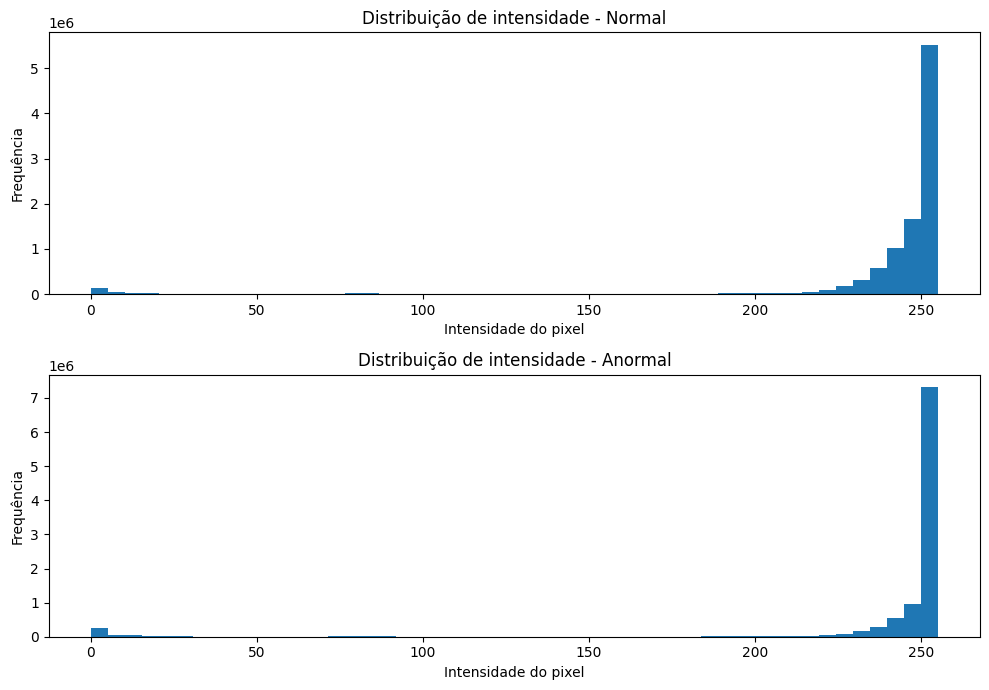


3. RESUMO DAS INTENSIDADES
Normal
Intensidade média: 238.76
Desvio médio: 43.42
Anormal
Intensidade média: 239.39
Desvio médio: 50.75


In [5]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

random.seed(42)

# Seleção reproduzível de quatro imagens de cada classe
amostras_normal = random.sample(arquivos_normal, 4)
amostras_anormal = random.sample(arquivos_anormal, 4)

amostras = {
    "Normal": (pasta_normal, amostras_normal),
    "Anormal": (pasta_anormal, amostras_anormal)
}

print("1. INSPEÇÃO VISUAL DAS CLASSES")

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for linha, (classe, (pasta, arquivos)) in enumerate(amostras.items()):
    for coluna, arquivo in enumerate(arquivos):
        caminho = os.path.join(pasta, arquivo)

        with Image.open(caminho) as imagem:
            axes[linha, coluna].imshow(imagem)
            axes[linha, coluna].set_title(classe)
            axes[linha, coluna].axis("off")

plt.tight_layout()
plt.show()

print("\n2. DISTRIBUIÇÃO DAS INTENSIDADES")

fig, axes = plt.subplots(2, 1, figsize=(10, 7))

for eixo, (classe, (pasta, arquivos)) in zip(axes, amostras.items()):
    intensidades = []

    for arquivo in arquivos:
        caminho = os.path.join(pasta, arquivo)

        with Image.open(caminho) as imagem:
            imagem_cinza = np.array(imagem.convert("L"))
            intensidades.extend(imagem_cinza.ravel())

    eixo.hist(intensidades, bins=50)
    eixo.set_title(f"Distribuição de intensidade - {classe}")
    eixo.set_xlabel("Intensidade do pixel")
    eixo.set_ylabel("Frequência")

plt.tight_layout()
plt.show()

print("\n3. RESUMO DAS INTENSIDADES")

for classe, (pasta, arquivos) in amostras.items():
    medias = []
    desvios = []

    for arquivo in arquivos:
        caminho = os.path.join(pasta, arquivo)

        with Image.open(caminho) as imagem:
            imagem_cinza = np.array(imagem.convert("L"))
            medias.append(imagem_cinza.mean())
            desvios.append(imagem_cinza.std())

    print(f"{classe}")
    print(f"Intensidade média: {np.mean(medias):.2f}")
    print(f"Desvio médio: {np.mean(desvios):.2f}")

##### Conclusão da Etapa 2

<small> A análise visual identificou imagens com fundo predominantemente claro, grade, traçados escuros e variações de apresentação. Os histogramas confirmaram forte concentração de pixels em intensidades elevadas e médias semelhantes entre as classes (238,76 Normal e 239,39 Anormal).

<small> Os resultados servirão de base para definir o pré-processamento, sem aplicação de filtros ou transformações nesta etapa.

---

## Etapa 3 — Pré-processamento básico

As imagens originais possuem resolução de **2105 × 1190 pixels e três canais RGB**, dimensão excessiva para utilização direta em uma MLP. Nesta etapa, é avaliada uma representação mais compacta e uniforme das imagens.

O pré-processamento proposto utiliza **escala de cinza**, redimensionamento para **128 × 128 pixels** e normalização das intensidades para o intervalo **[0, 1]**. A redução dimensional busca tornar o treinamento computacionalmente viável, enquanto a escala de cinza elimina a redundância dos três canais de cor.

Antes da aplicação ao dataset completo, são comparadas imagens originais e pré-processadas para verificar visualmente se os principais traçados do ECG permanecem reconhecíveis.

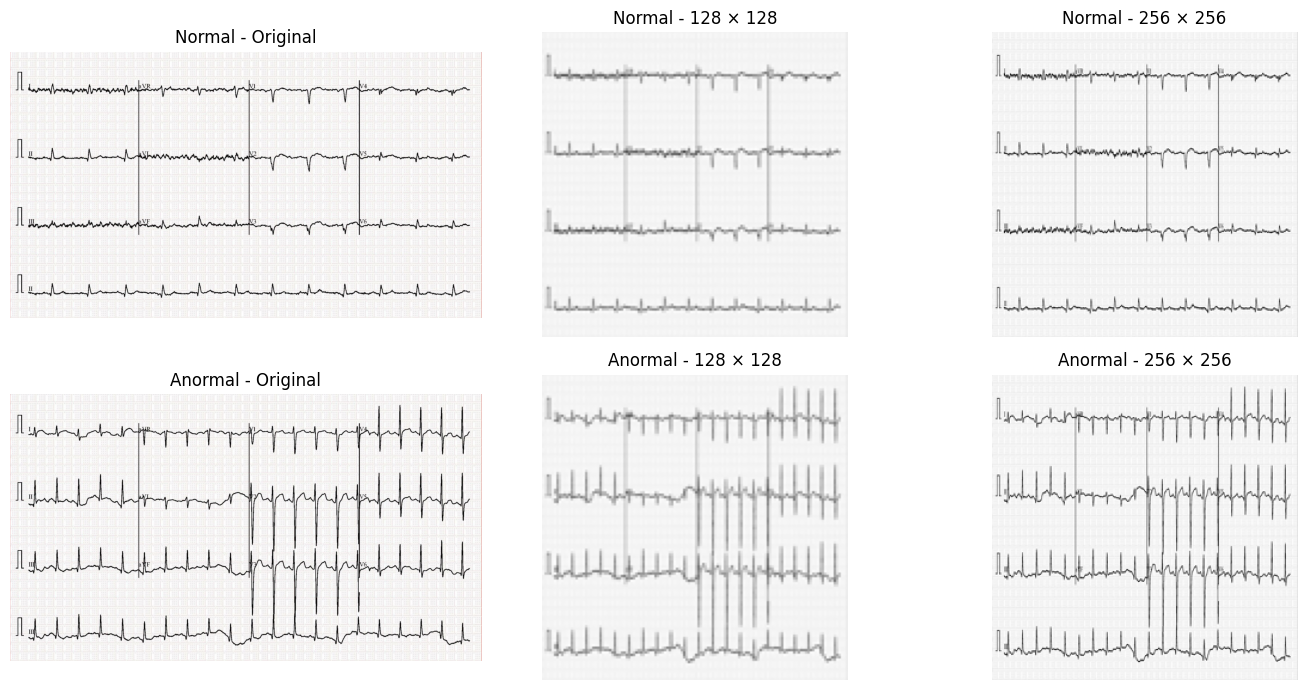

COMPARAÇÃO DAS RESOLUÇÕES

128 × 128
Entradas para a MLP: 16,384
Redução em relação à imagem original: 99.35%

256 × 256
Entradas para a MLP: 65,536
Redução em relação à imagem original: 97.38%


In [6]:
import os

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

TAMANHOS = [(128, 128), (256, 256)]

def preprocessar_imagem(caminho, tamanho):
    with Image.open(caminho) as imagem:
        imagem_cinza = imagem.convert("L")
        imagem_redimensionada = imagem_cinza.resize(tamanho)
        imagem_normalizada = (
            np.array(imagem_redimensionada, dtype=np.float32) / 255.0
        )

    return imagem_normalizada

# Uma amostra de cada classe
amostras = [
    ("Normal", os.path.join(pasta_normal, arquivos_normal[0])),
    ("Anormal", os.path.join(pasta_anormal, arquivos_anormal[0]))
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for linha, (classe, caminho) in enumerate(amostras):
    with Image.open(caminho) as original:
        axes[linha, 0].imshow(original)
        axes[linha, 0].set_title(f"{classe} - Original")
        axes[linha, 0].axis("off")

    for coluna, tamanho in enumerate(TAMANHOS, start=1):
        processada = preprocessar_imagem(caminho, tamanho)

        axes[linha, coluna].imshow(
            processada,
            cmap="gray",
            vmin=0,
            vmax=1
        )

        axes[linha, coluna].set_title(
            f"{classe} - {tamanho[0]} × {tamanho[1]}"
        )

        axes[linha, coluna].axis("off")

plt.tight_layout()
plt.show()

print("COMPARAÇÃO DAS RESOLUÇÕES")

for tamanho in TAMANHOS:
    quantidade_pixels = tamanho[0] * tamanho[1]

    print(f"\n{tamanho[0]} × {tamanho[1]}")
    print(f"Entradas para a MLP: {quantidade_pixels:,}")
    print(
        "Redução em relação à imagem original: "
        f"{(1 - quantidade_pixels / (2105 * 1190)) * 100:.2f}%"
    )

##### Conclusão da Etapa 3

<small>As imagens foram convertidas para tons de cinza, redimensionadas e normalizadas no intervalo [0,1].

A resolução **128 × 128** foi mantida por oferecer uma redução significativa da dimensionalidade, preservando os principais traçados visuais necessários para o experimento com MLP.



<small>A resolução 256 × 256 aumentaria consideravelmente a quantidade de entradas e de parâmetros da rede, sem justificativa suficiente para o escopo atual.

### Etapa 4 — Avaliação de filtragem

<small>Antes de incorporar filtros ao pipeline, foi realizada uma comparação visual entre as imagens pré-processadas sem filtro e uma versão com aplicação leve de nitidez.

O objetivo é verificar se o realce melhora a definição dos traçados do ECG sem destacar excessivamente a grade de fundo ou introduzir artefatos.

Nenhum filtro será incorporado ao dataset antes dessa avaliação visual.

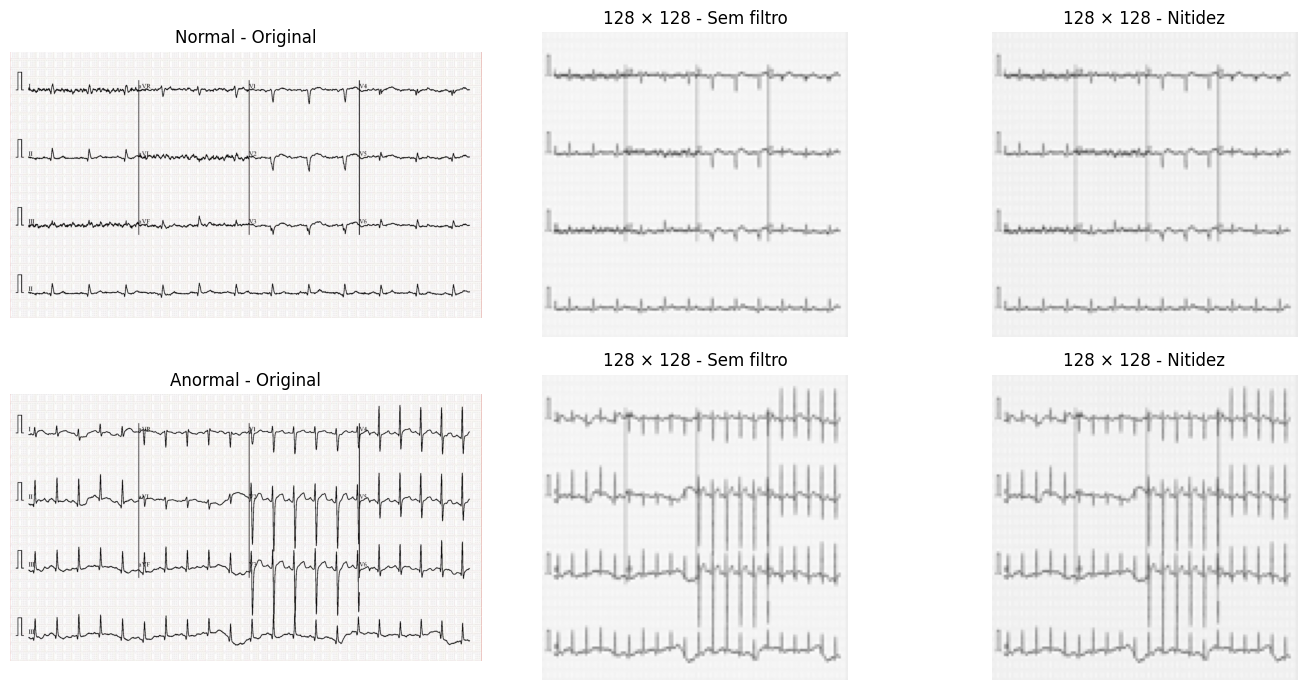

In [7]:
import os

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageFilter

TAMANHO_IMAGEM = (128, 128)

def preprocessar_sem_filtro(caminho):
    with Image.open(caminho) as imagem:
        imagem = imagem.convert("L")
        imagem = imagem.resize(TAMANHO_IMAGEM)

    return np.array(imagem, dtype=np.float32) / 255.0


def preprocessar_com_nitidez(caminho):
    with Image.open(caminho) as imagem:
        imagem = imagem.convert("L")

        # Aplicação leve de nitidez antes do redimensionamento
        imagem = imagem.filter(
            ImageFilter.UnsharpMask(
                radius=1,
                percent=120,
                threshold=3
            )
        )

        imagem = imagem.resize(TAMANHO_IMAGEM)

    return np.array(imagem, dtype=np.float32) / 255.0


amostras = [
    ("Normal", os.path.join(pasta_normal, arquivos_normal[0])),
    ("Anormal", os.path.join(pasta_anormal, arquivos_anormal[0]))
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for linha, (classe, caminho) in enumerate(amostras):

    with Image.open(caminho) as original:
        axes[linha, 0].imshow(original)
        axes[linha, 0].set_title(f"{classe} - Original")
        axes[linha, 0].axis("off")

    sem_filtro = preprocessar_sem_filtro(caminho)

    axes[linha, 1].imshow(
        sem_filtro,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[linha, 1].set_title("128 × 128 - Sem filtro")
    axes[linha, 1].axis("off")

    com_nitidez = preprocessar_com_nitidez(caminho)

    axes[linha, 2].imshow(
        com_nitidez,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[linha, 2].set_title("128 × 128 - Nitidez")
    axes[linha, 2].axis("off")

plt.tight_layout()
plt.show()

##### Conclusão da Etapa 4

<small>Foi avaliada a aplicação de um filtro leve de nitidez sobre as imagens de ECG antes do redimensionamento.

A comparação visual mostrou apenas uma pequena intensificação dos traçados, sem ganho suficientemente evidente de informação em relação às imagens pré-processadas sem filtro.

Como a filtragem também pode realçar elementos secundários, como a grade de fundo, optou-se por **não incorporar filtros ao pipeline definitivo**.



<small>O pré-processamento seguirá com conversão para tons de cinza, redimensionamento para 128 × 128 pixels e normalização no intervalo [0,1].

## Etapa 5 — Preparação e separação dos dados

As imagens são processadas conforme as decisões anteriores: conversão para **escala de cinza**, redimensionamento para **128 × 128** e normalização dos pixels para **[0, 1]**. Os rótulos são representados como **Normal = 0** e **Anormal = 1**.

O dataset é dividido em **70% treino, 15% validação e 15% teste**, utilizando separação estratificada para preservar aproximadamente a proporção entre as classes. O conjunto de teste permanece independente para a avaliação final do modelo.

In [8]:
import os

import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

TAMANHO_IMAGEM = (128, 128)

def preprocessar_imagem(caminho):
    with Image.open(caminho) as imagem:
        imagem_cinza = imagem.convert("L")
        imagem_redimensionada = imagem_cinza.resize(TAMANHO_IMAGEM)

        imagem_normalizada = (
            np.array(
                imagem_redimensionada,
                dtype=np.float32
            ) / 255.0
        )

    return imagem_normalizada


# Construção do dataset
imagens = []
rotulos = []

# Classe Normal = 0
for arquivo in arquivos_normal:
    caminho = os.path.join(pasta_normal, arquivo)

    imagens.append(
        preprocessar_imagem(caminho)
    )

    rotulos.append(0)


# Classe Anormal = 1
for arquivo in arquivos_anormal:
    caminho = os.path.join(pasta_anormal, arquivo)

    imagens.append(
        preprocessar_imagem(caminho)
    )

    rotulos.append(1)


X = np.array(imagens, dtype=np.float32)
y = np.array(rotulos, dtype=np.int32)

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

print("\nDistribuição total:")
print(f"Normal: {(y == 0).sum()}")
print(f"Anormal: {(y == 1).sum()}")


# Primeira divisão:
# 70% treino e 30% temporário
X_treino, X_temp, y_treino, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


# Segunda divisão:
# metade dos 30% para validação
# metade para teste
X_validacao, X_teste, y_validacao, y_teste = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)


def mostrar_distribuicao(nome, X_conjunto, y_conjunto):
    total = len(y_conjunto)

    normal = (y_conjunto == 0).sum()
    anormal = (y_conjunto == 1).sum()

    print(f"\n{nome}")
    print(f"Shape: {X_conjunto.shape}")

    print(
        f"Normal: {normal} "
        f"({normal / total * 100:.2f}%)"
    )

    print(
        f"Anormal: {anormal} "
        f"({anormal / total * 100:.2f}%)"
    )


mostrar_distribuicao(
    "Treino",
    X_treino,
    y_treino
)

mostrar_distribuicao(
    "Validação",
    X_validacao,
    y_validacao
)

mostrar_distribuicao(
    "Teste",
    X_teste,
    y_teste
)

Shape de X: (1405, 128, 128)
Shape de y: (1405,)

Distribuição total:
Normal: 859
Anormal: 546

Treino
Shape: (983, 128, 128)
Normal: 601 (61.14%)
Anormal: 382 (38.86%)

Validação
Shape: (211, 128, 128)
Normal: 129 (61.14%)
Anormal: 82 (38.86%)

Teste
Shape: (211, 128, 128)
Normal: 129 (61.14%)
Anormal: 82 (38.86%)


##### Conclusão da Etapa 5

<small>As 1.405 imagens foram pré-processadas em tons de cinza, redimensionadas para 128 × 128 pixels e normalizadas no intervalo [0,1].

O conjunto foi dividido de forma estratificada em **70% para treino, 15% para validação e 15% para teste**, utilizando `random_state=42` para garantir reprodutibilidade.



<small>A proporção entre as classes Normal e Anormal foi preservada nos três conjuntos, e o conjunto de teste permanecerá reservado até a avaliação final do modelo selecionado.

### Etapa 6 — Construção da MLP

<small>Foi construída uma rede neural do tipo **Multilayer Perceptron (MLP)** para classificação binária das imagens de ECG.

Cada imagem de 128 × 128 pixels é convertida em um vetor de 16.384 entradas pela camada `Flatten`.

A rede utiliza duas camadas densas ocultas com 128 e 64 neurônios, ambas com ativação ReLU, seguidas por uma camada de saída com um neurônio e ativação sigmoid.

A arquitetura possui **2.105.601 parâmetros treináveis**.

In [9]:
from tensorflow import keras
from tensorflow.keras import layers

keras.utils.set_random_seed(42)

modelo = keras.Sequential([
    layers.Input(shape=(128, 128)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,105,601 (8.03 MB)

 Trainable params: 2,105,601 (8.03 MB)

 Non-trainable params: 0 (0.00 B)

##### Conclusão da Etapa 6

<small> Foi construída uma MLP baseline com entrada **128 × 128**, seguida por `Flatten`, duas camadas densas de **128 e 64 neurônios** e uma saída `sigmoid` para classificação binária.



<small> A arquitetura possui **2.105.601 parâmetros treináveis** e foi mantida simples para que seu comportamento seja avaliado antes de possíveis ajustes estruturais.

## Etapa 7 — Treinamento da MLP

A MLP baseline é treinada utilizando **SGD (Stochastic Gradient Descent)**, seguindo o processo iterativo de ajuste dos pesos apresentado no Capítulo 06. Foram definidos `batch_size=32`, taxa de aprendizagem de **0,01** e **50 épocas**, ampliando o período de treinamento para observar com maior clareza a evolução do aprendizado.

Por se tratar de classificação binária com saída `sigmoid`, utiliza-se `binary_crossentropy` como função de perda e **acurácia** como métrica principal. O conjunto de validação acompanha o comportamento do modelo durante o treinamento, enquanto o conjunto de teste permanece reservado.

### Experimento 1 — Controle da aleatoriedade

Para estabelecer uma referência reprodutível, foi fixada uma semente antes da criação e do treinamento de uma nova MLP. A arquitetura baseline e os demais parâmetros foram mantidos: **128–64 neurônios**, SGD com taxa de aprendizagem **0,01**, `batch_size=32` e **70 épocas**.

O objetivo foi estabelecer uma execução controlada de referência para avaliar posteriormente o impacto de alterações nos parâmetros de treinamento.

In [10]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import SGD
import numpy as np

keras.utils.set_random_seed(42)

modelo_sgd_001 = keras.Sequential([
    layers.Input(shape=(128, 128)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

modelo_sgd_001.compile(
    optimizer=SGD(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

historico_sgd_001 = modelo_sgd_001.fit(
    X_treino,
    y_treino,
    validation_data=(X_validacao, y_validacao),
    epochs=70,
    batch_size=32,
    verbose=0
)

melhor_epoca_sgd_001 = np.argmax(
    historico_sgd_001.history["val_accuracy"]
)

print("EXPERIMENTO 1 — SGD 0.01")
print(f"Melhor época: {melhor_epoca_sgd_001 + 1}")
print(
    f"Acurácia de treino: "
    f"{historico_sgd_001.history['accuracy'][melhor_epoca_sgd_001]:.4f}"
)
print(
    f"Acurácia de validação: "
    f"{historico_sgd_001.history['val_accuracy'][melhor_epoca_sgd_001]:.4f}"
)
print(
    f"Loss de validação: "
    f"{historico_sgd_001.history['val_loss'][melhor_epoca_sgd_001]:.4f}"
)

EXPERIMENTO 1 — SGD 0.01
Melhor época: 60
Acurácia de treino: 0.6663
Acurácia de validação: 0.7725
Loss de validação: 0.5918


### Experimento 2 — Ajuste da taxa de aprendizagem e número de épocas

Mantendo a mesma arquitetura, divisão dos dados, semente e `batch_size`, a taxa de aprendizagem do SGD foi reduzida de **0,01 para 0,001** para investigar seu impacto na estabilidade do treinamento.

Após a redução da taxa, foram realizados testes exploratórios com diferentes números de épocas. O treinamento apresentou evolução progressiva até atingir sua melhor acurácia de validação na **época 126**. Um teste adicional até 250 épocas não apresentou melhora desse resultado.

Dessa forma, foram adotadas **150 épocas** como configuração de referência, mantendo margem suficiente para alcançar o melhor desempenho observado sem prolongar desnecessariamente o treinamento.

In [11]:
keras.utils.set_random_seed(42)

modelo_sgd_0001 = keras.Sequential([
    layers.Input(shape=(128, 128)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

modelo_sgd_0001.compile(
    optimizer=SGD(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

historico_sgd_0001 = modelo_sgd_0001.fit(
    X_treino,
    y_treino,
    validation_data=(X_validacao, y_validacao),
    epochs=150,
    batch_size=32,
    verbose=0
)

melhor_epoca_sgd_0001 = np.argmax(
    historico_sgd_0001.history["val_accuracy"]
)

print("EXPERIMENTO 2 — SGD 0.001")
print(f"Melhor época: {melhor_epoca_sgd_0001 + 1}")
print(
    f"Acurácia de treino: "
    f"{historico_sgd_0001.history['accuracy'][melhor_epoca_sgd_0001]:.4f}"
)
print(
    f"Acurácia de validação: "
    f"{historico_sgd_0001.history['val_accuracy'][melhor_epoca_sgd_0001]:.4f}"
)
print(
    f"Loss de validação: "
    f"{historico_sgd_0001.history['val_loss'][melhor_epoca_sgd_0001]:.4f}"
)

EXPERIMENTO 2 — SGD 0.001
Melhor época: 126
Acurácia de treino: 0.7314
Acurácia de validação: 0.8246
Loss de validação: 0.5129


### Etapa 8 — Análise das curvas de treinamento

As curvas de acurácia e perda foram analisadas para verificar o comportamento do treinamento e possíveis sinais de underfitting ou overfitting.

O experimento com **SGD e learning rate 0.001** apresentou evolução gradual da acurácia ao longo das épocas, com comportamento relativamente estável entre treino e validação.

A melhor acurácia de validação foi utilizada como referência para identificar a época de melhor desempenho do modelo.

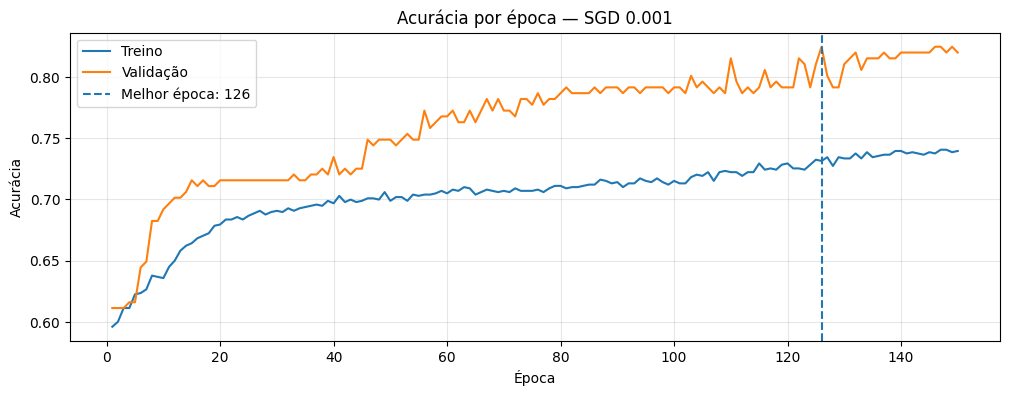

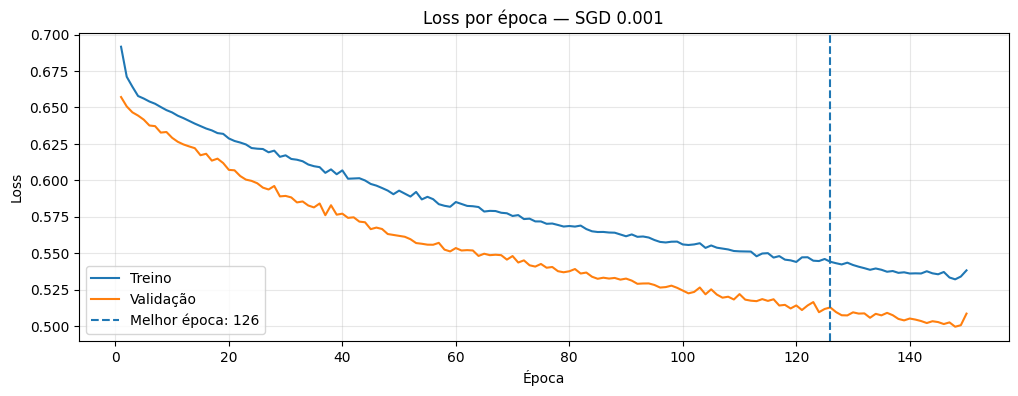

In [12]:
import matplotlib.pyplot as plt

epocas = range(
    1,
    len(historico_sgd_0001.history["accuracy"]) + 1
)

melhor_epoca = melhor_epoca_sgd_0001 + 1

# Gráfico de acurácia
plt.figure(figsize=(12, 4))

plt.plot(
    epocas,
    historico_sgd_0001.history["accuracy"],
    label="Treino"
)

plt.plot(
    epocas,
    historico_sgd_0001.history["val_accuracy"],
    label="Validação"
)

plt.axvline(
    melhor_epoca,
    linestyle="--",
    label=f"Melhor época: {melhor_epoca}"
)

plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.title("Acurácia por época — SGD 0.001")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Gráfico de loss
plt.figure(figsize=(12, 4))

plt.plot(
    epocas,
    historico_sgd_0001.history["loss"],
    label="Treino"
)

plt.plot(
    epocas,
    historico_sgd_0001.history["val_loss"],
    label="Validação"
)

plt.axvline(
    melhor_epoca,
    linestyle="--",
    label=f"Melhor época: {melhor_epoca}"
)

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Loss por época — SGD 0.001")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

##### Conclusão da Etapa 8

<small>A redução da taxa de aprendizagem do SGD para **0,001** tornou o treinamento mais estável, com redução progressiva das perdas e aumento das acurácias. Com até **150 épocas**, a melhor acurácia de validação foi **82,46%**, obtida na época 126, sem evidência acentuada de overfitting.

<small>Um teste exploratório estendido até **250 épocas** não superou a melhor acurácia obtida na época 126, indicando redução dos ganhos adicionais. Assim, **150 épocas** foram mantidas como configuração de referência para os próximos experimentos.

### Etapa 9 — Comparação de arquiteturas

<small>Foram comparadas três arquiteturas MLP com diferentes quantidades de neurônios nas camadas ocultas, mantendo constantes o pré-processamento, o otimizador SGD com learning rate 0,001, o batch size, a quantidade máxima de épocas e a seed.

O objetivo foi verificar se o aumento da capacidade da rede produziria ganho consistente na acurácia de validação.

As arquiteturas avaliadas foram:

- 64–32;
- 128–64;
- 256–128.

In [13]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import SGD
import numpy as np

arquiteturas = {
    "64-32": (64, 32),
    "128-64": (128, 64),
    "256-128": (256, 128)
}

modelos = {}
historicos = {}
resultados = []

for nome, (n1, n2) in arquiteturas.items():

    keras.utils.set_random_seed(42)

    modelo_exp = keras.Sequential([
        layers.Input(shape=(128, 128)),
        layers.Flatten(),
        layers.Dense(n1, activation="relu"),
        layers.Dense(n2, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    modelo_exp.compile(
        optimizer=SGD(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    historico_exp = modelo_exp.fit(
        X_treino,
        y_treino,
        validation_data=(X_validacao, y_validacao),
        epochs=150,
        batch_size=32,
        verbose=0
    )

    melhor_epoca = np.argmax(
        historico_exp.history["val_accuracy"]
    )

    modelos[nome] = modelo_exp
    historicos[nome] = historico_exp

    resultados.append({
        "arquitetura": nome,
        "parametros": modelo_exp.count_params(),
        "melhor_epoca": melhor_epoca + 1,
        "acc_treino":
            historico_exp.history["accuracy"][melhor_epoca],
        "acc_validacao":
            historico_exp.history["val_accuracy"][melhor_epoca],
        "loss_validacao":
            historico_exp.history["val_loss"][melhor_epoca]
    })

print("COMPARAÇÃO DAS ARQUITETURAS\n")

for resultado in resultados:
    print(f"Arquitetura: {resultado['arquitetura']}")
    print(f"Parâmetros: {resultado['parametros']:,}")
    print(f"Melhor época: {resultado['melhor_epoca']}")
    print(f"Acurácia de treino: {resultado['acc_treino']:.4f}")
    print(f"Acurácia de validação: {resultado['acc_validacao']:.4f}")
    print(f"Loss de validação: {resultado['loss_validacao']:.4f}")
    print()

COMPARAÇÃO DAS ARQUITETURAS

Arquitetura: 64-32
Parâmetros: 1,050,753
Melhor época: 124
Acurácia de treino: 0.7192
Acurácia de validação: 0.8009
Loss de validação: 0.5154

Arquitetura: 128-64
Parâmetros: 2,105,601
Melhor época: 126
Acurácia de treino: 0.7314
Acurácia de validação: 0.8246
Loss de validação: 0.5129

Arquitetura: 256-128
Parâmetros: 4,227,585
Melhor época: 139
Acurácia de treino: 0.7396
Acurácia de validação: 0.8104
Loss de validação: 0.5075



##### Conclusão da Etapa 9

<small>A arquitetura **128–64** apresentou a melhor acurácia de validação entre as configurações avaliadas, alcançando **82,46%**.

O aumento da capacidade para 256–128 elevou significativamente o número de parâmetros, mas não produziu ganho de acurácia, enquanto a arquitetura 64–32 também apresentou desempenho inferior.

<small>Assim, a arquitetura **128–64** foi mantida como configuração de referência para os próximos experimentos, por apresentar o melhor equilíbrio entre desempenho e complexidade.

### Experimento 3 — Otimizador Adam

<small>Após os experimentos com SGD, a arquitetura **128–64** apresentou a melhor acurácia de validação. Entretanto, o aumento da capacidade da rede para 256–128 não produziu ganho de desempenho.

Neste experimento, será mantida a arquitetura 128–64, substituindo o otimizador SGD pelo **Adam**, com taxa de aprendizagem de 0,0005.

O objetivo é verificar se um otimizador adaptativo melhora a convergência e o desempenho da MLP.

**Configuração experimental:**
- Resolução: 128 × 128 pixels;
- Pré-processamento: tons de cinza, sem filtros e normalização [0,1];
- Arquitetura: 128–64;
- Otimizador: Adam;
- Learning rate: 0,0005;
- Batch size: 32;
- Épocas: 150;
- Seed: 42;
- Função de perda: binary crossentropy.

<small>Os conjuntos de treino e validação permanecem inalterados. O conjunto de teste continua reservado para a avaliação final.

EXPERIMENTO 3 — ADAM 0.0005 | 128 × 128
Parâmetros: 2,105,601
Melhor época: 137
Acurácia de treino: 0.8535
Acurácia de validação: 0.8483
Loss de validação: 0.3752


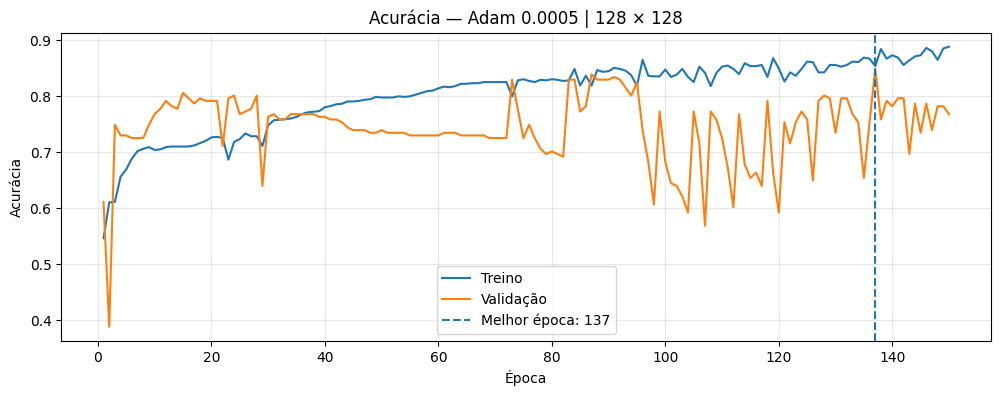

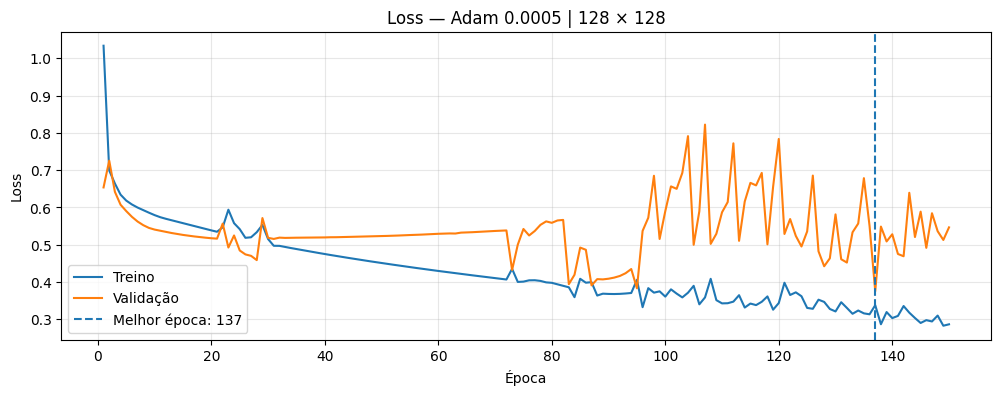

In [14]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt

# Reprodutibilidade
keras.utils.set_random_seed(42)

# Arquitetura 128–64
modelo_adam = keras.Sequential([
    layers.Input(shape=(128, 128)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

# Compilação
modelo_adam.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Treinamento
historico_adam = modelo_adam.fit(
    X_treino,
    y_treino,
    validation_data=(X_validacao, y_validacao),
    epochs=150,
    batch_size=32,
    verbose=0
)

# Melhor época pela acurácia de validação
melhor_epoca_adam = np.argmax(
    historico_adam.history["val_accuracy"]
)

print("EXPERIMENTO 3 — ADAM 0.0005 | 128 × 128")
print(f"Parâmetros: {modelo_adam.count_params():,}")
print(f"Melhor época: {melhor_epoca_adam + 1}")
print(
    f"Acurácia de treino: "
    f"{historico_adam.history['accuracy'][melhor_epoca_adam]:.4f}"
)
print(
    f"Acurácia de validação: "
    f"{historico_adam.history['val_accuracy'][melhor_epoca_adam]:.4f}"
)
print(
    f"Loss de validação: "
    f"{historico_adam.history['val_loss'][melhor_epoca_adam]:.4f}"
)

# Gráfico de acurácia
epocas = range(
    1,
    len(historico_adam.history["accuracy"]) + 1
)

plt.figure(figsize=(12, 4))

plt.plot(
    epocas,
    historico_adam.history["accuracy"],
    label="Treino"
)

plt.plot(
    epocas,
    historico_adam.history["val_accuracy"],
    label="Validação"
)

plt.axvline(
    melhor_epoca_adam + 1,
    linestyle="--",
    label=f"Melhor época: {melhor_epoca_adam + 1}"
)

plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.title("Acurácia — Adam 0.0005 | 128 × 128")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Gráfico de perda
plt.figure(figsize=(12, 4))

plt.plot(
    epocas,
    historico_adam.history["loss"],
    label="Treino"
)

plt.plot(
    epocas,
    historico_adam.history["val_loss"],
    label="Validação"
)

plt.axvline(
    melhor_epoca_adam + 1,
    linestyle="--",
    label=f"Melhor época: {melhor_epoca_adam + 1}"
)

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Loss — Adam 0.0005 | 128 × 128")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

##### Conclusão do Experimento 3

<small>O uso do otimizador **Adam**, com learning rate de **0,0005**, apresentou o melhor desempenho entre as configurações avaliadas, alcançando **84,83% de acurácia de validação** na época 137.

Nesse ponto, a acurácia de treino foi de **85,35%**, resultando em uma diferença de apenas **0,52 ponto percentual** entre treino e validação, indicando boa capacidade de generalização naquele momento do treinamento. A loss de validação foi de **0,3752**.

Apesar do melhor desempenho, as curvas de validação apresentaram oscilações ao longo das épocas, enquanto o desempenho no conjunto de treino continuou evoluindo. Esse comportamento indica **instabilidade no treinamento e sinais de overfitting em determinados períodos**, sem invalidar o melhor ponto de generalização alcançado.



<small>Assim, a configuração **MLP 128–64, Adam 0,0005, batch size 32, imagens 128 × 128 e seed 42** foi selecionada como a melhor configuração experimental e seguirá para a avaliação final no conjunto de teste, mantido separado durante todo o processo de seleção.

## Etapa 10 — Seleção final e avaliação no conjunto de teste

<small>Após os experimentos controlados, a configuração com melhor desempenho de validação foi selecionada para a avaliação final.

A configuração escolhida utiliza uma MLP com camadas ocultas **128–64**, imagens em **128 × 128 pixels**, otimizador **Adam** com learning rate de **0,0005**, batch size 32 e seed 42.

Durante o Experimento 3, a melhor acurácia de validação foi obtida na **época 137**. Por esse motivo, o modelo final será reconstruído e treinado exatamente por 137 épocas antes da avaliação no conjunto de teste.

O conjunto de teste, composto por **211 imagens**, permaneceu separado durante todo o processo de escolha da arquitetura e dos hiperparâmetros, evitando sua utilização na seleção do modelo.

AVALIAÇÃO FINAL — CONJUNTO DE TESTE

CONFIGURAÇÃO FINAL
Resolução:             128 × 128
Arquitetura:           128–64
Otimizador:            Adam
Learning rate:         0.0005
Batch size:            32
Épocas:                137
Threshold:             0.50
Parâmetros:            2,105,601

DESEMPENHO NO TESTE
Imagens avaliadas:     211
Loss de teste:         0.3394
Acurácia de teste:     0.8436
Acurácia percentual:   84.36%

MATRIZ DE CONFUSÃO
[[115  14]
 [ 19  63]]


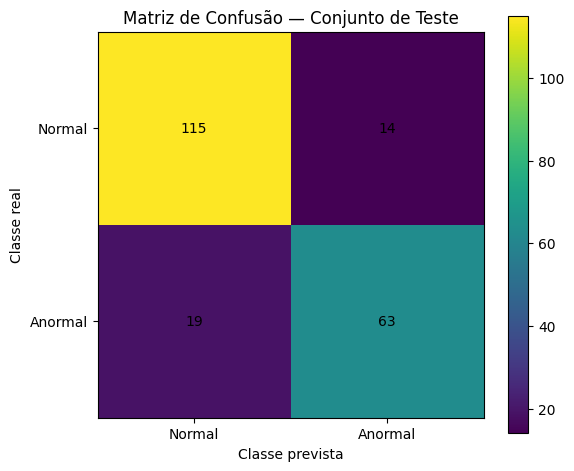

In [18]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ETAPA 10 — MODELO FINAL E AVALIAÇÃO NO CONJUNTO DE TESTE
# ============================================================

# Reprodutibilidade
keras.utils.set_random_seed(42)

# Configuração final selecionada
EPOCAS_FINAIS = 137
BATCH_SIZE = 32
LEARNING_RATE = 0.0005
THRESHOLD = 0.50

# Modelo final
modelo_final = keras.Sequential([
    layers.Input(shape=(128, 128)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

modelo_final.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Treinamento com a configuração selecionada
modelo_final.fit(
    X_treino,
    y_treino,
    epochs=EPOCAS_FINAIS,
    batch_size=BATCH_SIZE,
    verbose=0
)

# Avaliação final no conjunto de teste
loss_teste, acuracia_teste = modelo_final.evaluate(
    X_teste,
    y_teste,
    verbose=0
)

# Probabilidades e classes previstas
prob_teste = modelo_final.predict(
    X_teste,
    verbose=0
).ravel()

predicoes_teste = (
    prob_teste >= THRESHOLD
).astype(int)

# Confirmação da acurácia
acuracia_confirmada = accuracy_score(
    y_teste,
    predicoes_teste
)

# Matriz de confusão
matriz = confusion_matrix(
    y_teste,
    predicoes_teste
)

# ============================================================
# RESULTADOS
# ============================================================

print("=" * 55)
print("AVALIAÇÃO FINAL — CONJUNTO DE TESTE")
print("=" * 55)

print("\nCONFIGURAÇÃO FINAL")
print(f"Resolução:             128 × 128")
print(f"Arquitetura:           128–64")
print(f"Otimizador:            Adam")
print(f"Learning rate:         {LEARNING_RATE}")
print(f"Batch size:            {BATCH_SIZE}")
print(f"Épocas:                {EPOCAS_FINAIS}")
print(f"Threshold:             {THRESHOLD:.2f}")
print(f"Parâmetros:            {modelo_final.count_params():,}")

print("\nDESEMPENHO NO TESTE")
print(f"Imagens avaliadas:     {len(y_teste)}")
print(f"Loss de teste:         {loss_teste:.4f}")
print(f"Acurácia de teste:     {acuracia_teste:.4f}")
print(f"Acurácia percentual:   {acuracia_teste * 100:.2f}%")

print("\nMATRIZ DE CONFUSÃO")
print(matriz)

# Visualização da matriz de confusão
plt.figure(figsize=(6, 5))
plt.imshow(matriz)

plt.title("Matriz de Confusão — Conjunto de Teste")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")

plt.xticks(
    [0, 1],
    ["Normal", "Anormal"]
)

plt.yticks(
    [0, 1],
    ["Normal", "Anormal"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            matriz[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

##### Conclusão da Etapa 10

<small>A configuração final com arquitetura **128–64**, otimizador **Adam** e learning rate de **0,0005** foi avaliada sobre o conjunto de teste composto por **211 imagens**, mantido separado durante todo o processo de seleção do modelo.

O modelo alcançou **84,36% de acurácia no teste**, com loss de **0,3394**, resultado muito próximo dos **84,83% obtidos na melhor época de validação**.

A diferença de apenas **0,47 ponto percentual** entre validação e teste indica comportamento consistente nesta divisão dos dados e sugere que o melhor desempenho observado na validação não ficou restrito apenas ao conjunto utilizado para seleção.

A matriz de confusão apresentou **115 classificações corretas de imagens normais e 63 classificações corretas de imagens anormais**, além de **14 falsos positivos e 19 falsos negativos**.

----

<small>O resultado final demonstra capacidade de generalização dentro do conjunto experimental utilizado, mas deve ser interpretado considerando as limitações do dataset, da arquitetura MLP e do contexto acadêmico da solução.

## Etapa 11 — IA Responsável

Por se tratar de uma aplicação relacionada à saúde, o classificador deve ser interpretado como uma ferramenta experimental de **apoio à triagem e à decisão médica**, e não como um sistema autônomo de diagnóstico.

A acurácia final de **84,36% no conjunto de teste** demonstra capacidade de classificação no conjunto avaliado, mas também evidencia a existência de erros. Portanto, uma classificação produzida pelo modelo não deve substituir a avaliação de profissionais da saúde.

Também devem ser considerados possíveis vieses relacionados à representatividade do dataset. Como os dados utilizados não fornecem informações suficientes para avaliar o desempenho entre diferentes grupos de pacientes, não é possível afirmar que o modelo apresenta comportamento equivalente para diferentes populações.

A transparência sobre o dataset, pré-processamento, arquitetura, experimentos, desempenho e limitações contribui para uma utilização mais responsável da solução.

----

##### Conclusão da Etapa 11

<small>O modelo deve ser utilizado apenas como recurso experimental de **apoio à triagem**, mantendo supervisão humana e reconhecendo possíveis limitações de representatividade e generalização.

<small>A acurácia obtida não autoriza interpretação clínica autônoma, sendo necessária transparência sobre os dados, resultados e limitações do sistema.

## Etapa 12 — Sustentabilidade

A eficiência computacional também foi considerada durante o desenvolvimento. O pré-processamento reduziu as imagens para **128 × 128 em escala de cinza**, diminuindo significativamente a quantidade de entradas da MLP em relação às imagens RGB originais.

Na comparação controlada de arquiteturas, aumentar a rede de **128–64 para 256–128** elevou o número de parâmetros de **2.105.601 para 4.227.585**, sem melhorar a acurácia de validação, que passou de **82,46% para 81,04%** naquele experimento.

Posteriormente, a arquitetura 128–64 foi mantida nos experimentos com o otimizador Adam, evitando aumentar a complexidade da rede sem evidência de benefício.

Esse resultado está alinhado ao princípio de **Green AI**, no qual desempenho e custo computacional devem ser considerados conjuntamente, evitando complexidade adicional quando ela não produz benefício mensurável.

----

##### Conclusão da Etapa 12

<small>A arquitetura **128–64** apresentou melhor equilíbrio entre desempenho e complexidade, superando uma rede aproximadamente duas vezes maior em número de parâmetros na comparação realizada.

<small>As decisões de resolução e arquitetura contribuíram para limitar custos computacionais desnecessários sem comprometer o melhor resultado obtido no projeto.

## Etapa 13 — Limitações

Apesar dos resultados obtidos, algumas limitações devem ser consideradas:

- A **MLP** transforma as imagens em vetores por meio do `Flatten`, não explorando diretamente a estrutura espacial dos ECGs como arquiteturas específicas para imagens poderiam fazer.

- O dataset contém **1.405 imagens**, com distribuição moderadamente desbalanceada entre as classes Normal (61,14%) e Anormal (38,86%).

- A resolução foi reduzida para **128 × 128**, diminuindo a complexidade computacional, mas também reduzindo detalhes presentes nas imagens originais.

- A avaliação principal utiliza **acurácia**, conforme solicitado pela atividade, não sendo suficiente isoladamente para caracterizar todos os tipos de erro relevantes em uma aplicação médica.

- Não foram disponibilizados metadados suficientes para avaliar representatividade ou desempenho entre diferentes grupos de pacientes.

- O treinamento com Adam apresentou oscilações nas métricas de validação ao longo das épocas, apesar de atingir um ponto de boa generalização.

- O desempenho foi avaliado sobre uma divisão específica do dataset e não representa validação clínica do modelo.

----

##### Conclusão da Etapa 13

<small>A acurácia final de **84,36% no conjunto de teste** deve ser interpretada dentro das características do dataset, do pré-processamento e das limitações da arquitetura MLP utilizada.

<small>Os resultados demonstram a viabilidade experimental da abordagem, mas não permitem generalizar seu desempenho para utilização clínica real.

## Etapa 14 — Conclusão Final

O projeto desenvolveu uma solução de classificação binária de imagens de ECG utilizando uma **MLP em Keras**, atendendo ao objetivo de distinguir registros classificados como **Normal** e **Anormal**.

Foram utilizadas **1.405 imagens**, submetidas à auditoria, análise visual e pré-processamento com conversão para escala de cinza, redimensionamento para **128 × 128** e normalização. Os dados foram separados de forma estratificada em conjuntos de treino, validação e teste.

Durante o desenvolvimento, foram realizados experimentos controlados com taxa de aprendizagem, quantidade de épocas, capacidade da rede e otimizadores. A redução do learning rate do SGD para **0,001** tornou o treinamento mais estável, enquanto a arquitetura **128–64** apresentou o melhor equilíbrio entre desempenho e complexidade entre as arquiteturas comparadas.

Posteriormente, a substituição do SGD pelo **Adam com learning rate de 0,0005** elevou a melhor acurácia de validação para **84,83%**, obtida na época 137. Nesse ponto, a acurácia de treino foi de **85,35%**, indicando pequena diferença entre treino e validação, embora tenham sido observadas oscilações nas curvas ao longo do treinamento.

A configuração final manteve a arquitetura **128–64**, com **2.105.601 parâmetros**, e foi treinada por 137 épocas antes da avaliação no conjunto de teste reservado.

No conjunto de teste, composto por **211 imagens**, o modelo alcançou **84,36% de acurácia** e loss de **0,3394**. A diferença de apenas **0,47 ponto percentual** em relação à melhor acurácia de validação indica comportamento consistente nesta divisão experimental.

A matriz de confusão mostrou **115 imagens normais classificadas corretamente e 63 imagens anormais classificadas corretamente**, além de **14 falsos positivos e 19 falsos negativos**, reforçando a necessidade de interpretar a solução como ferramenta experimental e não como sistema autônomo de diagnóstico.

-----

##### Conclusão da Etapa 14

<small>Os resultados demonstraram que uma MLP é capaz de aprender padrões relevantes para a classificação experimental das imagens de ECG utilizadas, alcançando **84,36% de acurácia em dados de teste não utilizados na seleção do modelo**.

<small>A proximidade entre a melhor acurácia de validação (**84,83%**) e a acurácia final de teste (**84,36%**) indica comportamento consistente nesta divisão experimental, embora a solução permaneça sujeita às limitações do dataset e da arquitetura utilizada.

<small>A aplicação deve ser compreendida como um recurso acadêmico de **apoio à triagem**, sem substituir avaliação médica ou representar validação clínica.